In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imtkaggleteam/household-power-consumption/household_power_consumption.csv


TASK 3: ENERGY FORECASTING
✅ Loaded 100000 rows
📋 Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage']...

First row sample: ['16/12/2006' '17:24:00' '4.216']

📅 Date column: Date
⏰ Time column: Time
⚡ Power column: Global_reactive_power

✅ Clean data: 72279 rows
📅 Date range: 2006-12-16 17:24:00 to 2007-02-24 04:03:00
⚡ Power range: 0.05 to 0.87 kW
🕐 Hourly data points: 1668
After outlier removal: 1591 points


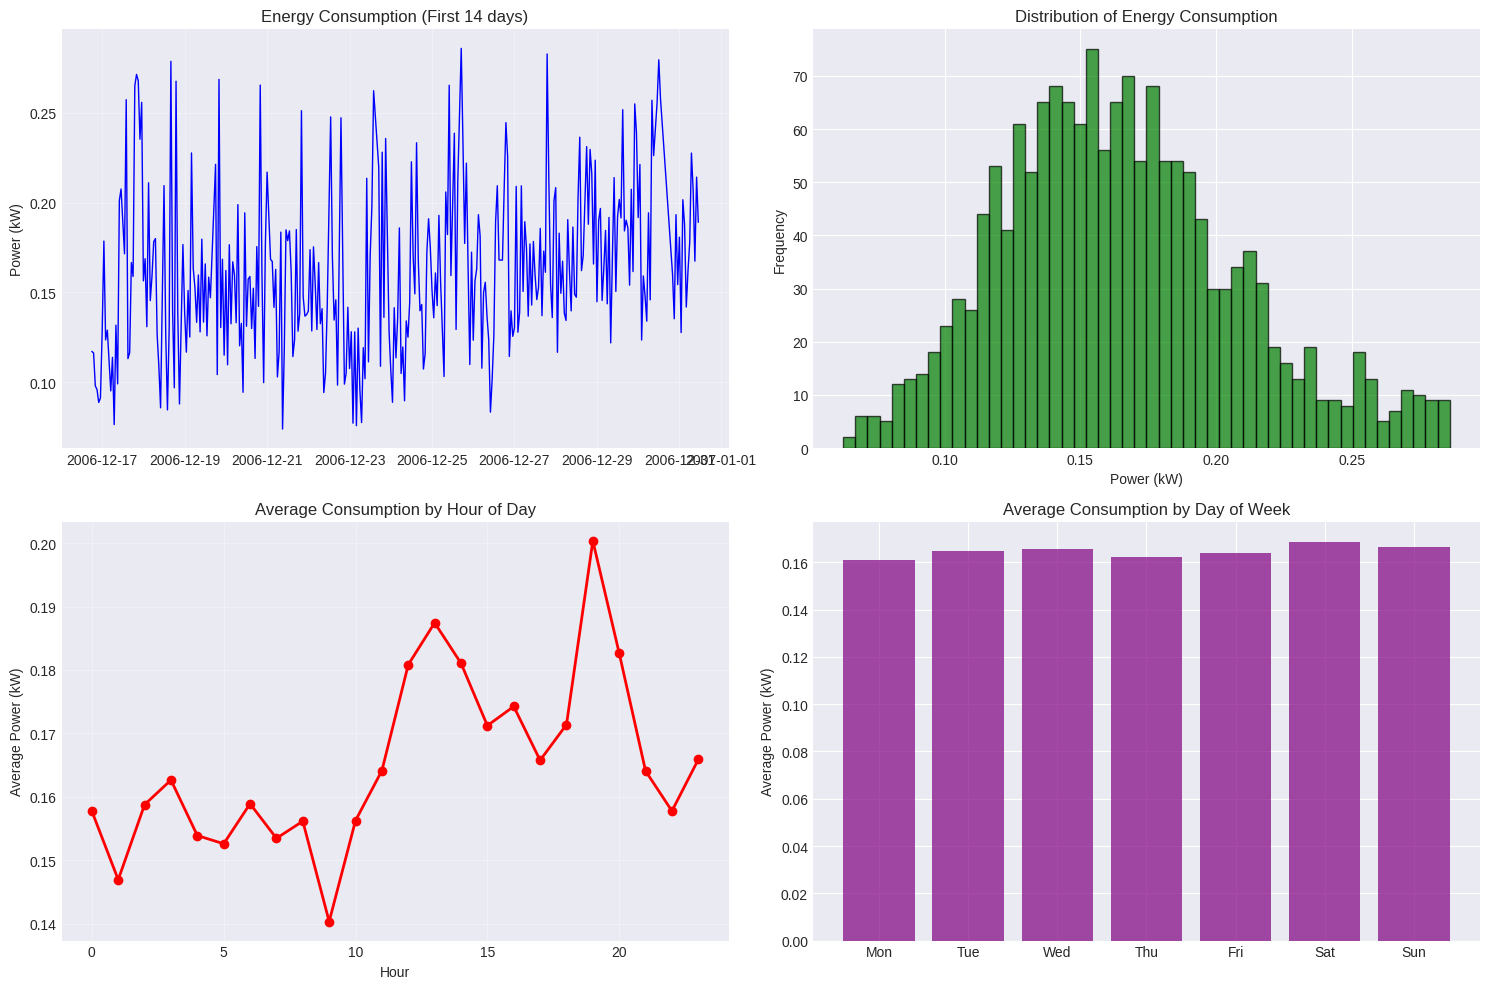

📊 Training set: 1272 hours (2006-12-16 18:00:00 to 2007-02-10 06:00:00)
📊 Test set: 319 hours (2007-02-10 07:00:00 to 2007-02-24 04:00:00)

🤖 Training Random Forest...
✅ Random Forest - MAE: 0.036 kW, RMSE: 0.045 kW

📈 Training Prophet (this may take 1-2 minutes)...


17:32:06 - cmdstanpy - INFO - Chain [1] start processing
17:32:06 - cmdstanpy - INFO - Chain [1] done processing


⚠️ Prophet failed: "[Timestamp('2007-02-23 14:00:00'), Timestamp('2007-02-23 15:00:00'), Timestamp('2007-02-23 16:00:00'), Timestamp('2007-02-23 17:00:00'), Timestamp('2007-02-23 18:00:00'), Timestamp('2007-02-23 19:00:00'), Timestamp('2007-02-23 20:00:00'), Timestamp('2007-02-23 21:00:00'), Timestamp('2007-02-23 22:00:00'), Timestamp('2007-02-23 23:00:00'), Timestamp('2007-02-24 00:00:00'), Timestamp('2007-02-24 01:00:00'), Timestamp('2007-02-24 02:00:00'), Timestamp('2007-02-24 03:00:00'), Timestamp('2007-02-24 04:00:00')] not in index"

🏆 Best Model: Random Forest (RMSE: 0.045 kW)


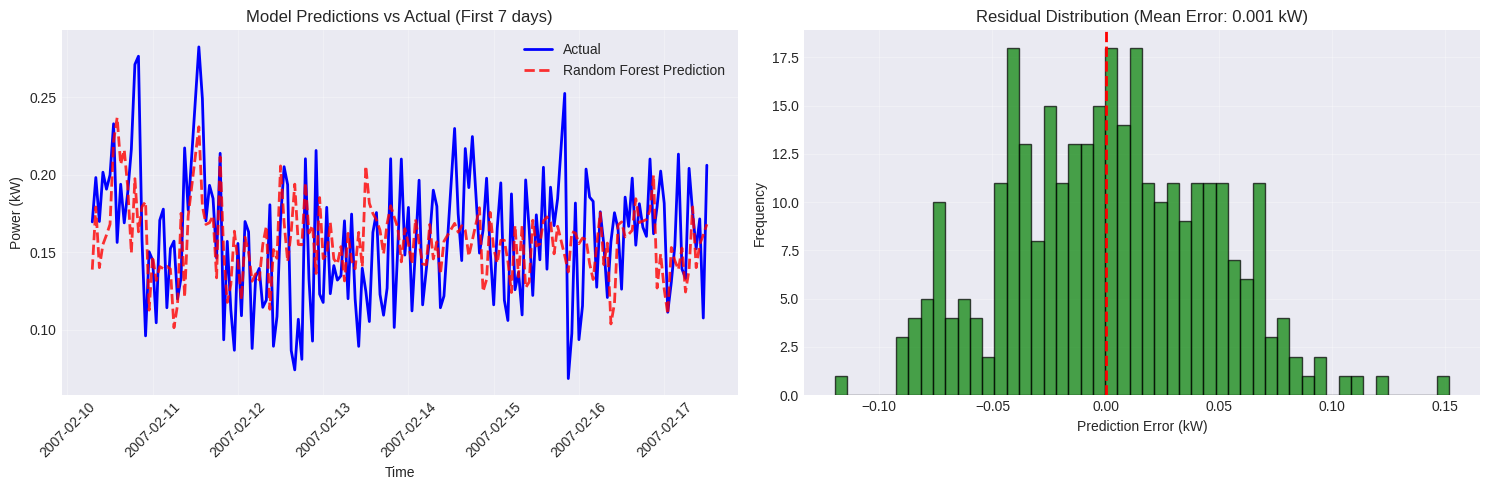

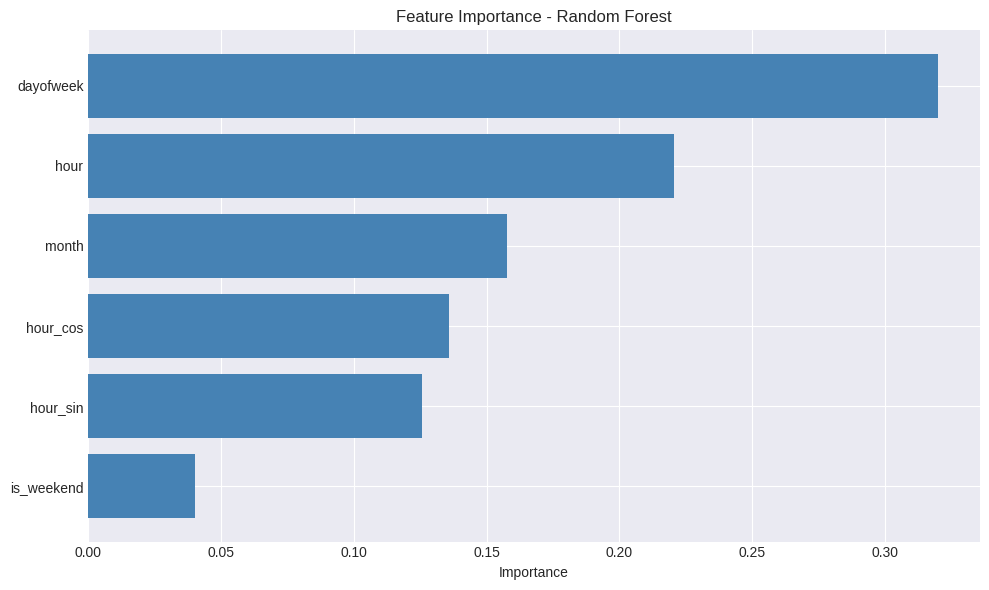


📊 FEATURE IMPORTANCE:
   feature  importance
 dayofweek    0.319909
      hour    0.220631
     month    0.157631
  hour_cos    0.136018
  hour_sin    0.125610
is_weekend    0.040201


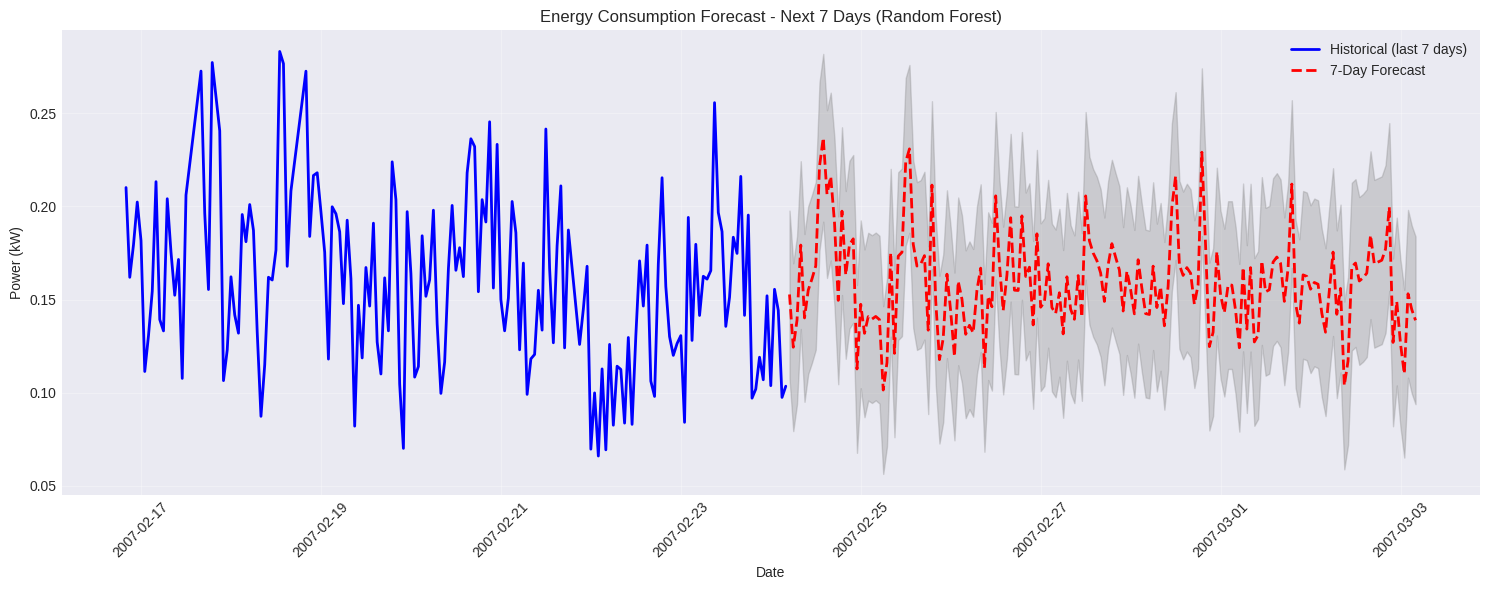


📈 7-DAY FORECAST SUMMARY:
Start date: 2007-02-24 05:00:00
End date: 2007-03-03 04:00:00
Peak forecast: 0.24 kW
Average forecast: 0.16 kW
Lowest forecast: 0.10 kW

✅ TASK 3 COMPLETED SUCCESSFULLY!
📊 Best Model: Random Forest
📈 RMSE: 0.045 kW
📈 MAE: 0.036 kW
📁 Outputs saved in /kaggle/working/

Generated files:
  - energy_analysis.png (EDA visualizations)
  - model_comparison.png (Predictions vs Actual)
  - feature_importance.png (Top features)
  - 7day_forecast.png (Future predictions)


In [4]:
# %% [markdown]
# # ⚡ Task 3: Energy Consumption Forecasting
# ## DevelopersHub Corporation - Data Science Internship

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print("="*60)
print("TASK 3: ENERGY FORECASTING")
print("="*60)

# %% [code]
# Load data - use comma as separator, NOT semicolon
# Also handle the header correctly
df = pd.read_csv(
    '/kaggle/input/datasets/imtkaggleteam/household-power-consumption/household_power_consumption.csv', 
    sep=',',  # Changed from ';' to ','
    low_memory=False, 
    nrows=100000  # Increased for better data
)

print(f"✅ Loaded {len(df)} rows")
print(f"📋 Columns: {df.columns.tolist()[:5]}...")

# Rename columns properly (they might be in first row)
if len(df.columns) == 1:
    # If all data is in one column, we need to parse it differently
    print("Detected single column - reparsing...")
    # Read again with proper parsing
    df = pd.read_csv(
        '/kaggle/input/datasets/imtkaggleteam/household-power-consumption/household_power_consumption.csv',
        sep=',',
        low_memory=False,
        nrows=100000,
        skipinitialspace=True
    )

# Check if first row contains headers
first_row = df.iloc[0] if len(df) > 0 else None
print(f"\nFirst row sample: {first_row.values[:3] if first_row is not None else 'N/A'}")

# Standard column names for this dataset
standard_columns = ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 
                    'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

# If columns are generic (0,1,2...), assign standard names
if df.columns.tolist() == list(range(len(df.columns))):
    df.columns = standard_columns[:len(df.columns)]
    print("Assigned standard column names")

# Now extract Date and Time columns
date_col = None
time_col = None
power_col = None

for col in df.columns:
    col_lower = str(col).lower()
    if 'date' in col_lower:
        date_col = col
    elif 'time' in col_lower:
        time_col = col
    elif 'global_active_power' in col_lower or ('power' in col_lower and col_lower != 'time'):
        power_col = col

print(f"\n📅 Date column: {date_col}")
print(f"⏰ Time column: {time_col}")
print(f"⚡ Power column: {power_col}")

# If we still don't have proper columns, use positional indices
if date_col is None and len(df.columns) >= 2:
    date_col = df.columns[0]
    time_col = df.columns[1]
    power_col = df.columns[2] if len(df.columns) > 2 else df.columns[2]

# Create datetime column
df['DateTime'] = pd.to_datetime(df[date_col] + ' ' + df[time_col], format='%d/%m/%Y %H:%M:%S', errors='coerce')

# Convert power to numeric
df[power_col] = pd.to_numeric(df[power_col], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['DateTime', power_col])
df = df[df[power_col] > 0]  # Remove zero/negative readings

print(f"\n✅ Clean data: {len(df)} rows")
print(f"📅 Date range: {df['DateTime'].min()} to {df['DateTime'].max()}")
print(f"⚡ Power range: {df[power_col].min():.2f} to {df[power_col].max():.2f} kW")

# %% [code]
# Resample to hourly
df.set_index('DateTime', inplace=True)
hourly = df[power_col].resample('H').mean().dropna().reset_index()
hourly.columns = ['ds', 'y']

print(f"🕐 Hourly data points: {len(hourly)}")

# Remove outliers (optional - improves forecast)
Q1 = hourly['y'].quantile(0.25)
Q3 = hourly['y'].quantile(0.75)
IQR = Q3 - Q1
hourly = hourly[(hourly['y'] >= Q1 - 1.5*IQR) & (hourly['y'] <= Q3 + 1.5*IQR)]
print(f"After outlier removal: {len(hourly)} points")

# Feature engineering for ML
hourly['hour'] = hourly['ds'].dt.hour
hourly['dayofweek'] = hourly['ds'].dt.dayofweek
hourly['month'] = hourly['ds'].dt.month
hourly['is_weekend'] = (hourly['dayofweek'] >= 5).astype(int)
hourly['hour_sin'] = np.sin(2 * np.pi * hourly['hour'] / 24)
hourly['hour_cos'] = np.cos(2 * np.pi * hourly['hour'] / 24)

# %% [code]
# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot (first 2 weeks if available)
days_to_plot = min(336, len(hourly))
axes[0,0].plot(hourly['ds'][:days_to_plot], hourly['y'][:days_to_plot], linewidth=1, color='blue')
axes[0,0].set_title(f'Energy Consumption (First {days_to_plot//24} days)')
axes[0,0].set_ylabel('Power (kW)')
axes[0,0].grid(True, alpha=0.3)

# Distribution
axes[0,1].hist(hourly['y'], bins=50, edgecolor='black', color='green', alpha=0.7)
axes[0,1].set_title('Distribution of Energy Consumption')
axes[0,1].set_xlabel('Power (kW)')
axes[0,1].set_ylabel('Frequency')

# Hourly pattern
hourly_avg = hourly.groupby('hour')['y'].mean()
axes[1,0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='red')
axes[1,0].set_title('Average Consumption by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Average Power (kW)')
axes[1,0].grid(True, alpha=0.3)

# Weekly pattern
weekly_avg = hourly.groupby('dayofweek')['y'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1,1].bar(days, weekly_avg.values, color='purple', alpha=0.7)
axes[1,1].set_title('Average Consumption by Day of Week')
axes[1,1].set_ylabel('Average Power (kW)')

plt.tight_layout()
plt.savefig('/kaggle/working/energy_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [code]
# Train-test split (80-20 by time)
split_idx = int(len(hourly) * 0.8)
train = hourly.iloc[:split_idx].copy()
test = hourly.iloc[split_idx:].copy()

print(f"📊 Training set: {len(train)} hours ({train['ds'].min()} to {train['ds'].max()})")
print(f"📊 Test set: {len(test)} hours ({test['ds'].min()} to {test['ds'].max()})")

# Random Forest Model
features = ['hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos']
X_train, X_test = train[features], test[features]
y_train, y_test = train['y'], test['y']

print("\n🤖 Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"✅ Random Forest - MAE: {mae_rf:.3f} kW, RMSE: {rmse_rf:.3f} kW")

# %% [code]
# Prophet Model
print("\n📈 Training Prophet (this may take 1-2 minutes)...")
try:
    # Prepare data for Prophet
    train_prophet = train[['ds', 'y']].copy()
    train_prophet['ds'] = pd.to_datetime(train_prophet['ds'])
    
    prophet_model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode='multiplicative'
    )
    prophet_model.fit(train_prophet)
    
    # Create future dataframe
    future = prophet_model.make_future_dataframe(periods=len(test), freq='H')
    forecast = prophet_model.predict(future)
    
    # Align predictions
    test_dates = test['ds'].values
    prophet_pred = forecast.set_index('ds').loc[test_dates, 'yhat'].values
    
    mae_prophet = mean_absolute_error(test['y'], prophet_pred)
    rmse_prophet = np.sqrt(mean_squared_error(test['y'], prophet_pred))
    print(f"✅ Prophet - MAE: {mae_prophet:.3f} kW, RMSE: {rmse_prophet:.3f} kW")
    
    # Determine best model
    if rmse_prophet < rmse_rf:
        best_model = "Prophet"
        best_rmse = rmse_prophet
        best_pred = prophet_pred
    else:
        best_model = "Random Forest"
        best_rmse = rmse_rf
        best_pred = y_pred_rf
        
except Exception as e:
    print(f"⚠️ Prophet failed: {e}")
    best_model = "Random Forest"
    best_rmse = rmse_rf
    best_pred = y_pred_rf

print(f"\n🏆 Best Model: {best_model} (RMSE: {best_rmse:.3f} kW)")

# %% [code]
# Visualization of predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot first 168 hours (7 days) of test predictions
plot_length = min(168, len(test))
test_subset = test.iloc[:plot_length]
pred_subset = best_pred[:plot_length]

axes[0].plot(test_subset['ds'], test_subset['y'], label='Actual', linewidth=2, color='blue')
axes[0].plot(test_subset['ds'], pred_subset, label=f'{best_model} Prediction', linewidth=2, 
             color='red', linestyle='--', alpha=0.8)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Power (kW)')
axes[0].set_title(f'Model Predictions vs Actual (First {plot_length//24} days)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Residuals
residuals = test['y'].values[:len(best_pred)] - best_pred
axes[1].hist(residuals, bins=50, edgecolor='black', color='green', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (kW)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution (Mean Error: {residuals.mean():.3f} kW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [code]
# Feature Importance (for Random Forest)
if best_model == "Random Forest":
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title('Feature Importance - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('/kaggle/working/feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("\n📊 FEATURE IMPORTANCE:")
    print(importance_df.to_string(index=False))

# %% [code]
# 7-day Forecast
if len(hourly) >= 168:
    last_date = hourly['ds'].max()
    future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=168, freq='H')
    
    # Create features for future dates
    future_features = pd.DataFrame({
        'ds': future_dates,
        'hour': future_dates.hour,
        'dayofweek': future_dates.dayofweek,
        'month': future_dates.month,
        'is_weekend': (future_dates.dayofweek >= 5).astype(int),
        'hour_sin': np.sin(2 * np.pi * future_dates.hour / 24),
        'hour_cos': np.cos(2 * np.pi * future_dates.hour / 24)
    })
    
    # Make forecast
    future_forecast = rf.predict(future_features[features])
    
    # Plot
    plt.figure(figsize=(15, 6))
    plt.plot(hourly['ds'][-168:], hourly['y'][-168:], label='Historical (last 7 days)', 
             linewidth=2, color='blue')
    plt.plot(future_dates, future_forecast, label='7-Day Forecast', 
             linewidth=2, color='red', linestyle='--')
    plt.fill_between(future_dates, future_forecast - best_rmse, future_forecast + best_rmse, 
                     alpha=0.3, color='gray')
    plt.xlabel('Date')
    plt.ylabel('Power (kW)')
    plt.title(f'Energy Consumption Forecast - Next 7 Days ({best_model})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('/kaggle/working/7day_forecast.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Print forecast summary
    print("\n📈 7-DAY FORECAST SUMMARY:")
    print(f"Start date: {future_dates[0]}")
    print(f"End date: {future_dates[-1]}")
    print(f"Peak forecast: {future_forecast.max():.2f} kW")
    print(f"Average forecast: {future_forecast.mean():.2f} kW")
    print(f"Lowest forecast: {future_forecast.min():.2f} kW")

# %% [code]
# Final Summary
print("\n" + "="*60)
print("✅ TASK 3 COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"📊 Best Model: {best_model}")
print(f"📈 RMSE: {best_rmse:.3f} kW")
print(f"📈 MAE: {mae_rf:.3f} kW")
print(f"📁 Outputs saved in /kaggle/working/")
print("\nGenerated files:")
print("  - energy_analysis.png (EDA visualizations)")
print("  - model_comparison.png (Predictions vs Actual)")
print("  - feature_importance.png (Top features)")
print("  - 7day_forecast.png (Future predictions)")
print("="*60)